# Génération de Signaux d'Entrée pour l'IA (GAN)
Suite à la lecture de l'étude `ConsignesPlan.md`, ce notebook génère 3 signaux simulant les données de capteurs haute fréquence ($f_s = 100 000$ Hz) avec des pertes de données dynamiques régulières.

Chaque signal respecte les contraintes suivantes :
- Possède une fréquence de rotation $f_{rot}$ aléatoire choisie entre 1000 et 3000 Hz.
- Est composé d'une composante périodique (sinusoïde) et modulé par du bruit (bruit blanc).
- Comporte des segments de données manquantes (`NaN`) de manière cyclique, qui représentent aléatoirement 5% à 25% de chaque cycle.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Paramètres physiques basés sur l'étude
fs = 100000  # Fréquence d'échantillonnage (Hz)
duree = 0.05  # Durée du signal en secondes (50 ms)
t = torch.arange(0, duree, 1/fs)
nb_points = len(t)

signaux = []

for i in range(3):
    # Fréquence de rotation aléatoire entre 1000 et 3000 Hz
    f_rot = torch.randint(1000, 3000, (1,)).item()
    
    # 2. Génération du signal de base : Sinusoïde + Bruit
    phase = torch.rand(1).item() * 2 * np.pi
    sinusoide = torch.sin(2 * np.pi * f_rot * t + phase)
    
    niveau_bruit = torch.rand(1).item() * 0.5 + 0.1
    bruit = torch.randn(nb_points) * niveau_bruit
    
    signal = sinusoide + bruit
    
    # 3. Création des trous (NaN) cycliques
    taille_cycle = int(fs / f_rot)
    nb_cycles = int(nb_points / taille_cycle)
    
    for cycle in range(nb_cycles):
        # Taux de perte par cycle (entre 5% et 25%)
        taux_perte = torch.rand(1).item() * 0.20 + 0.05
        taille_trou = max(1, int(taille_cycle * taux_perte))
        
        # Positionnement du trou dans le cycle (la position varie légèrement)
        marge = max(1, taille_cycle - taille_trou)
        debut_trou = cycle * taille_cycle + torch.randint(0, marge, (1,)).item()
        fin_trou = debut_trou + taille_trou
        
        # Injection des valeurs non définies (NaN)
        signal[debut_trou:fin_trou] = torch.nan
        
    signaux.append(signal)

# 4. Stockage sous forme d'un unique tableau PyTorch (Tensor)
# Shape : (3, nb_points)
tensor_signaux = torch.stack(signaux)

print(f"Format du tenseur généré : {tensor_signaux.shape}")
print(f"Nombre de valeurs nulles (NaN) par signal : {torch.isnan(tensor_signaux).sum(dim=1).tolist()}")

Format du tenseur généré : torch.Size([3, 5000])
Nombre de valeurs nulles (NaN) par signal : [647, 704, 658]


## Visualisation des Signaux
Aperçu des signaux générés avec leurs trous (les zones `NaN` provoquent des discontinuités naturelles sur le graphe temporel).

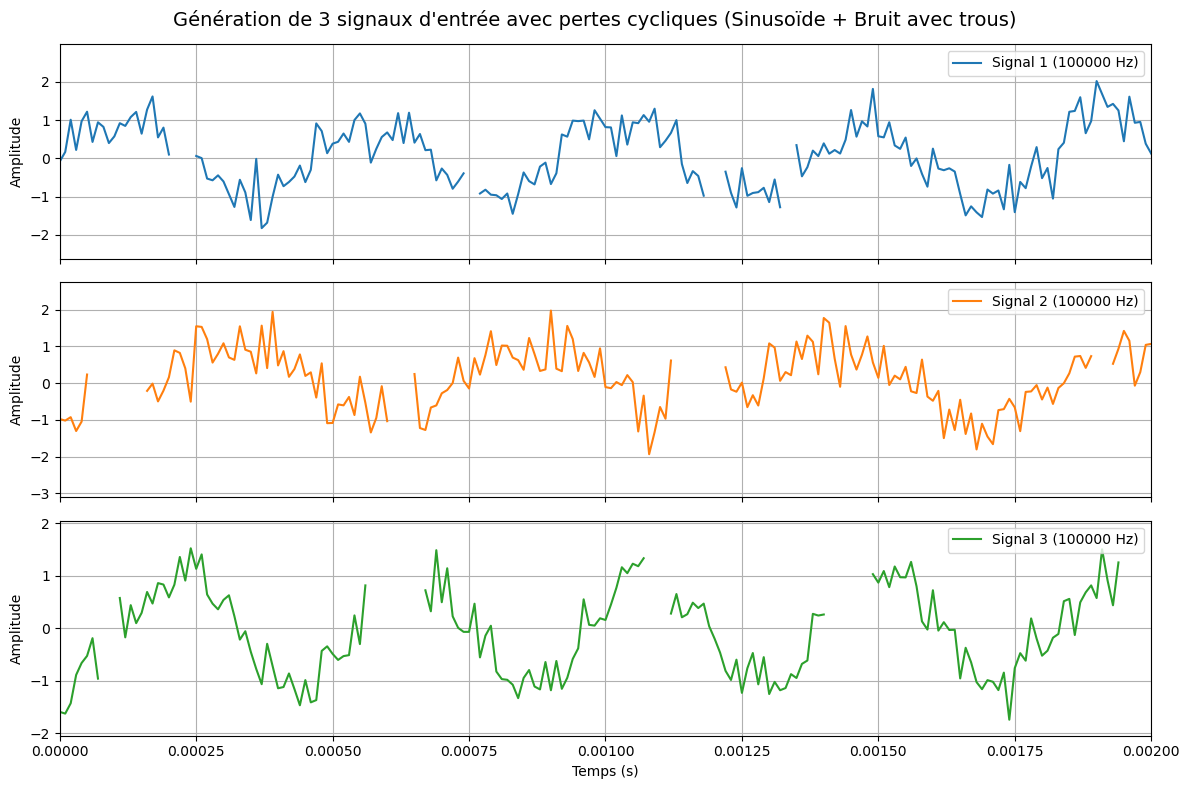

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i in range(3):
    # Les zones en NaN ne seront pas connectées par matplotlib, ce qui met visuellement en évidence les trous perceptibles.
    axes[i].plot(t.numpy(), tensor_signaux[i].numpy(), label=f'Signal {i+1} ({fs} Hz)', color=f'C{i}')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

axes[-1].set_xlabel('Temps (s)')
plt.suptitle("Génération de 3 signaux d'entrée avec pertes cycliques (Sinusoïde + Bruit avec trous)", fontsize=14)
plt.tight_layout()
plt.show()

## Exportation du tenseur
Afin de pouvoir utiliser ces signaux générés dans les autres modules du projet (entraînement du GAN, constitution du Dataset), nous sauvegardons le tenseur PyTorch dans un fichier `.pt`.

In [ ]:
# Export du tenseur PyTorch dans un fichier natif
fichier_sortie = 'signaux_entree_dataset.pt'
torch.save(tensor_signaux, fichier_sortie)

print(f"✅ Tenseur exporté avec succès vers le fichier : '{fichier_sortie}'")
print(f"   Pour le recharger plus tard : tensor_charge = torch.load('{fichier_sortie}')")